In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [0],
              [0],
              [1]])

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoidder(a):

    return a * (1 - a)


In [20]:
inputsize = 2
hiddensize = 1
outputsize = 1

np.random.seed(5)

W1 = np.random.randn(inputsize, hiddensize) * 0.01
b1 = np.zeros((1, hiddensize))

W2 = np.random.randn(hiddensize, outputsize) * 0.01
b2 = np.zeros((1, outputsize))


In [26]:
def forwardpropagation(X):
    x1 = np.dot(X, W1) + b1
    a1 = sigmoid(x1)

    x2 = np.dot(a1, W2) + b2
    ypred = sigmoid(x2)

    return x1, a1, x2, ypred


In [28]:
def computeloss(y,ypred):
  return np.mean((y-ypred)**2)

In [9]:
def backpropagation(X, y, x1, a1, x2, ypred):
    global W1, b1, W2, b2

    # Output layer error
    erroroutput = ypred - y
    doutput = erroroutput * sigmoidder(ypred)

    # Hidden layer error
    errorhidden = np.dot(doutput, W2.T)
    dhidden = errorhidden * sigmoidder(a1)

    # Gradients
    dW2 = np.dot(a1.T, doutput)
    db2 = np.sum(doutput, axis=0, keepdims=True)

    dW1 = np.dot(X.T, dhidden)
    db1 = np.sum(dhidden, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


In [11]:
def updateparameters(dW1, db1, dW2, db2, lr):
    global W1, b1, W2, b2

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2


In [39]:
epochs = 10000
learningrate = 0.1
losses = []

for epoch in range(epochs):
    x1, a1, x2, y_hat = forwardpropagation(X)
    loss = computeloss(y, y_hat)
    losses.append(loss)

    dW1, db1, dW2, db2 = backpropagation(X, y, x1, a1, x2, y_hat)
    updateparameters(dW1, db1, dW2, db2, learningrate)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.2500
Epoch 1000, Loss: 0.1373
Epoch 2000, Loss: 0.0299
Epoch 3000, Loss: 0.0098
Epoch 4000, Loss: 0.0052
Epoch 5000, Loss: 0.0034
Epoch 6000, Loss: 0.0025
Epoch 7000, Loss: 0.0020
Epoch 8000, Loss: 0.0016
Epoch 9000, Loss: 0.0014


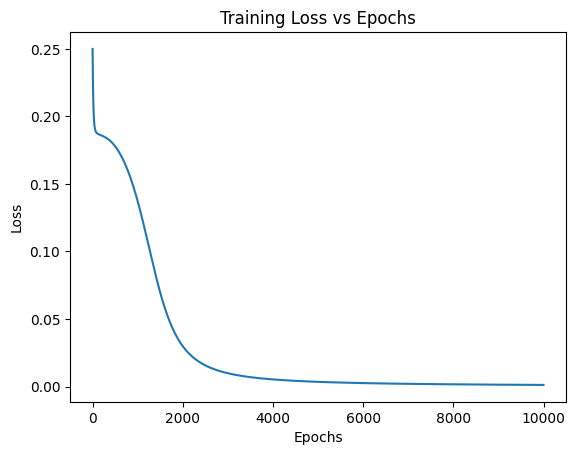

In [40]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()


In [ ]:
def predict(X):
    _, _, _, y_hat = forwardpropagation(X)
    return (y_hat > 0.5).astype(int)

print("Predictions:")
print(predict(X))
print("Actual:")
print(y)
